In [5]:
import numpy as np

In [6]:
import pandas as pd

In [ ]:
import numpy as np
import pandas as pd
import requests

# bounding box România
south = 43.6
north = 48.3
west = 20.2
east = 29.7

api_key = "f8344de0a4d1faac94e1648b06f1b5c4"

url = "https://portal.opentopography.org/API/globaldem"

params = {
    "demtype": "SRTMGL1",   # 30m
    "south": south,
    "north": north,
    "west": west,
    "east": east,
    "outputFormat": "GTiff",
    "API_Key": api_key
}

response = requests.get(url, params=params)

with open("romania_dem.tif", "wb") as f:
    f.write(response.content)

print("Download complete!")
with open("romania_dem.tif", "rb") as f:
    print(f.read(200))
import rasterio
import pandas as pd
import numpy as np

with rasterio.open("romania_dem.tif") as src:
    elevation = src.read(1)
    transform = src.transform
# rows, cols = elevation.shape
#
# data = []
#
# for row in range(rows):
#     for col in range(cols):
#         lon, lat = transform * (col, row)
#         alt = elevation[row, col]
#         data.append([lat, lon, alt])
#
# df = pd.DataFrame(data, columns=["lat", "lon", "elevation"])


Download complete!
b'II*\x00\xc0\x00\x00\x00GDAL_STRUCTURAL_METADATA_SIZE=000140 bytes\nLAYOUT=IFDS_BEFORE_DATA\nBLOCK_ORDER=ROW_MAJOR\nBLOCK_LEADER=SIZE_AS_UINT4\nBLOCK_TRAILER=LAST_4_BYTES_REPEATED\nKNOWN_INCOMPATIBLE_EDITION=NO\n \x00\x13\x00\x00\x01\x03\x00\x01\x00'


ModuleNotFoundError: No module named 'rasterio'

File size: 430.44 MB


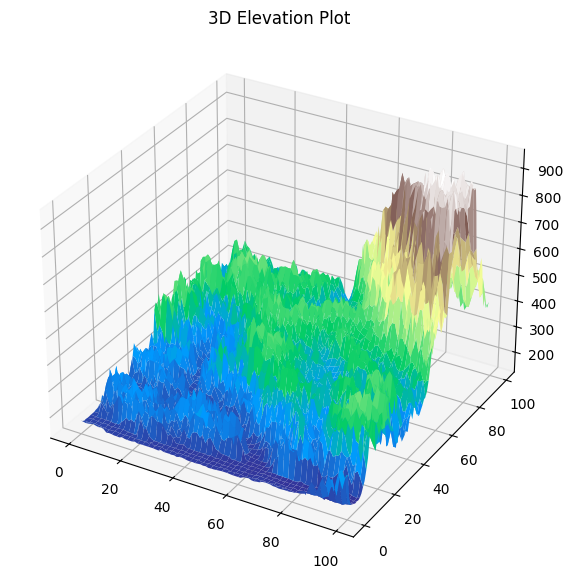

Download complete!
DEM shape: (1620, 1800)
Resolution: (0.0002777777777778146, 0.0002777777777778146)


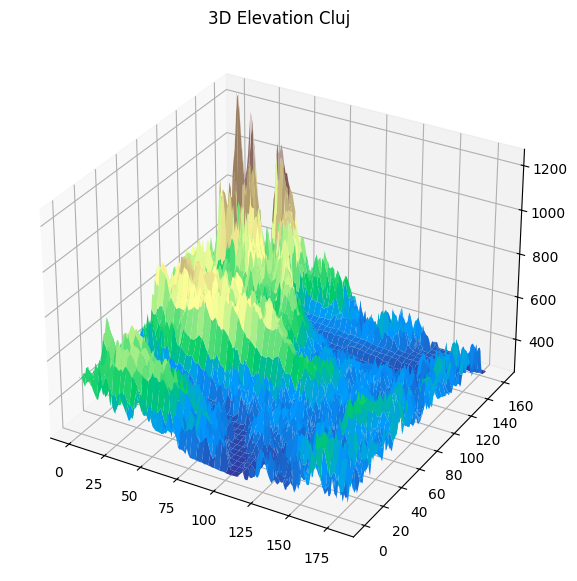

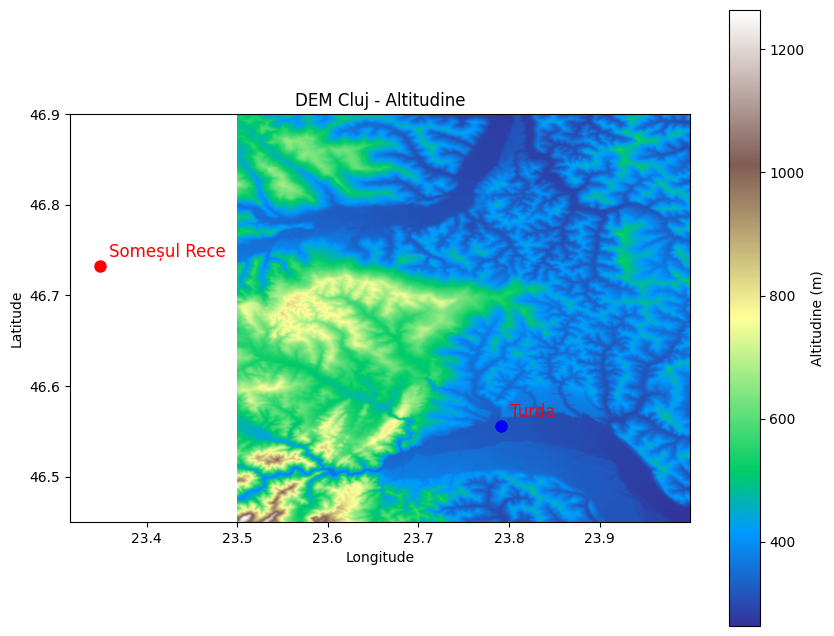

        date  precipitation_mm
0 2026-01-01               0.1
1 2026-01-02               5.0
2 2026-01-03              12.8
3 2026-01-04               3.7
4 2026-01-05               7.8


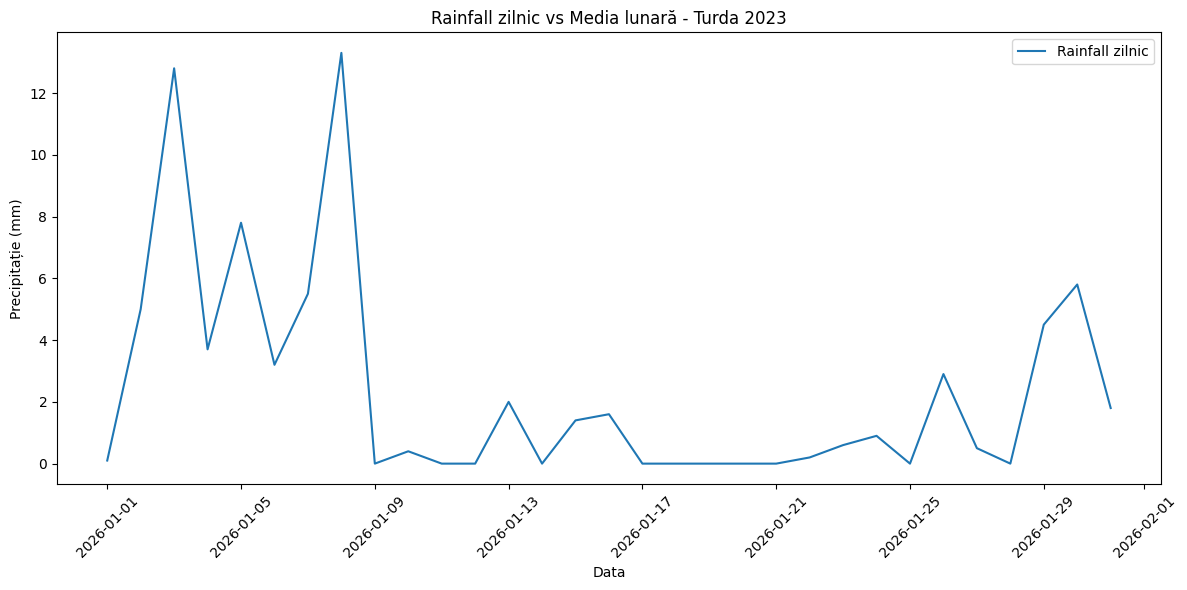

Altitudine: 331 metri


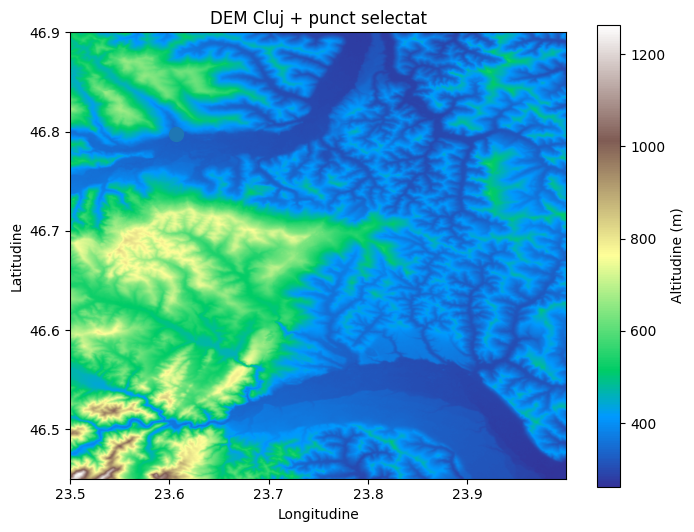

Inside raster: True


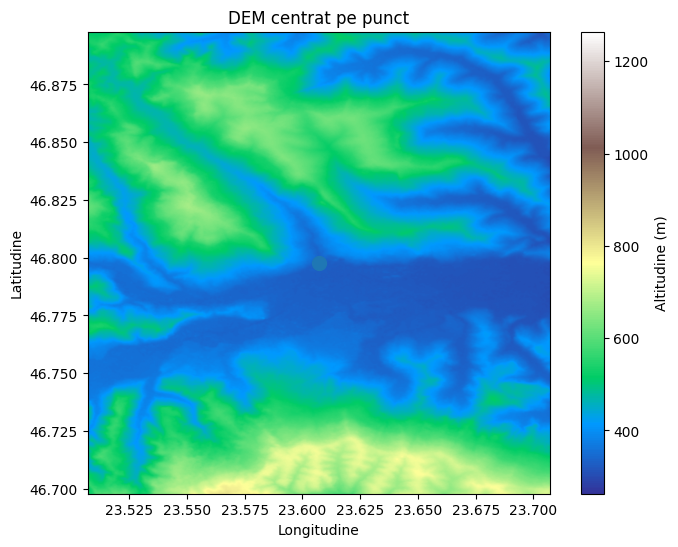

In [13]:

import os
size_mb = os.path.getsize("romania_dem.tif") / (1024*1024)
print(f"File size: {size_mb:.2f} MB")
import rasterio
import numpy as np

with rasterio.open("romania_dem.tif") as src:
    # citim doar o fereastră mică (ex: 1000x1000 pixeli)
    window = rasterio.windows.Window(0, 0, 1000, 1000)
    elevation = src.read(1, window=window)
elevation_small = elevation[::10, ::10]
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

rows, cols = elevation_small.shape
x = np.arange(cols)
y = np.arange(rows)
x, y = np.meshgrid(x, y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x, y, elevation_small, cmap='terrain')

ax.set_title("3D Elevation Plot")
plt.show()
south = 46.45   # min lat
north = 46.90   # max lat
west  = 23.50   # min lon
east  = 24.00   # max lon
import requests

api_key = "f8344de0a4d1faac94e1648b06f1b5c4"  # pune cheia ta reală

url = "https://portal.opentopography.org/API/globaldem"
params = {
    "demtype": "SRTMGL1",
    "south": south,
    "north": north,
    "west": west,
    "east": east,
    "outputFormat": "GTiff",
    "API_Key": api_key
}

response = requests.get(url, params=params)

with open("cluj_dem.tif", "wb") as f:
    f.write(response.content)

print("Download complete!")
import rasterio
import numpy as np

with rasterio.open("cluj_dem.tif") as src:
    elevation = src.read(1)  # citim banda 1
    transform = src.transform

print("DEM shape:", elevation.shape)
print("Resolution:", src.res)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# downsample ca să nu explodeze RAM-ul
elev_small = elevation[::10, ::10]

rows, cols = elev_small.shape
x = np.arange(cols)
y = np.arange(rows)
x, y = np.meshgrid(x, y)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, elev_small, cmap='terrain')

ax.set_title("3D Elevation Cluj")
plt.show()
import rasterio
import matplotlib.pyplot as plt
marker_lat = 46.7320067
marker_lon = 23.348195
# citește DEM
with rasterio.open("cluj_dem.tif") as src:
    elevation = src.read(1)
    bounds = src.bounds

# plot 2D
plt.figure(figsize=(10, 8))

lon_turda =  23.791158942971947

lat_turda = 46.55542872797168

# imshow cu colormap pentru altitudine
plt.imshow(elevation, cmap='terrain', extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
plt.colorbar(label='Altitudine (m)')
plt.plot(marker_lon, marker_lat, marker='o', color='red', markersize=8)
plt.text(marker_lon + 0.01, marker_lat + 0.01, "Someșul Rece", color='red', fontsize=12)

plt.plot(lon_turda, lat_turda, marker='o', color='blue', markersize=8)
plt.text(lon_turda + 0.01, lat_turda + 0.01, "Turda", color='red', fontsize=12)

plt.title("DEM Cluj - Altitudine")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
import requests
import pandas as pd
import matplotlib.pyplot as plt

lat_turda = 46.55542872797168
lon_turda = 23.791158942971947

start_date = "2026-01-01"
end_date = "2026-01-31"

url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={lat_turda}&longitude={lon_turda}"
    f"&start_date={start_date}&end_date={end_date}"
    f"&daily=precipitation_sum&timezone=Europe%2FBucharest"
)

response = requests.get(url)
data = response.json()

# transformăm în DataFrame
df = pd.DataFrame({
    "date": data["daily"]["time"],
    "precipitation_mm": data["daily"]["precipitation_sum"]
})

df["date"] = pd.to_datetime(df["date"])

print(df.head())
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Rainfall zilnic
plt.plot(df["date"], df["precipitation_mm"], label="Rainfall zilnic")

# Media lunară
plt.plot(
         linewidth=3,
         label="Media lunară")

plt.xlabel("Data")
plt.ylabel("Precipitație (mm)")
plt.title("Rainfall zilnic vs Media lunară - Turda 2023")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
import rasterio

lat = 46.797843802779006
lon = 23.607039880016337

with rasterio.open("cluj_dem.tif") as src:
    # transform coordonatele geografice în poziție raster
    row, col = src.index(lon, lat)

    elevation = src.read(1)[row, col]

print("Altitudine:", elevation, "metri")
import rasterio
import matplotlib.pyplot as plt

lat = 46.797843802779006
lon = 23.607039880016337

with rasterio.open("cluj_dem.tif") as src:
    dem = src.read(1)
    bounds = src.bounds

    # transform coordonate -> pixel
    row, col = src.index(lon, lat)

plt.figure(figsize=(8,6))

# afișăm rasterul
plt.imshow(dem, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],cmap="terrain" )
plt.colorbar(label="Altitudine (m)")

# adăugăm punctul
plt.scatter(lon, lat, marker="o", s=100)

plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.title("DEM Cluj + punct selectat")
plt.show()
# 46.64826364783387, 23.96884526572247
# 46.62784248597168, 23.26224183454979
# 46.9013385223667, 23.248722636249298
# 46.797843802779006, 23.607039880016337
from shapely.geometry import Point, box

with rasterio.open("cluj_dem.tif") as src:
    raster_bounds = box(*src.bounds)

point = Point(23.607039880016337, 46.797843802779006)

print("Inside raster:", raster_bounds.contains(point))
import rasterio
import matplotlib.pyplot as plt

lat = 46.797843802779006
lon = 23.607039880016337

buffer = 0.1  # cât de mult să facem zoom (în grade)

with rasterio.open("cluj_dem.tif") as src:
    dem = src.read(1)
    bounds = src.bounds

plt.figure(figsize=(8,6))

plt.imshow(
    dem,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
     cmap="terrain"
)

plt.colorbar(label="Altitudine (m)")

# punctul tău
plt.scatter(lon, lat, s=100)

# 🔥 centrăm pe punct
plt.xlim(lon - buffer, lon + buffer)
plt.ylim(lat - buffer, lat + buffer)

plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.title("DEM centrat pe punct")
plt.show()
import rasterio
import numpy as np
from PIL import Image

with rasterio.open("cluj_dem.tif") as src:
    dem = src.read(1)

# Normalizează între 0 și 255
dem_norm = 255 * (dem - np.min(dem)) / (np.max(dem) - np.min(dem))
dem_norm = dem_norm.astype(np.uint8)

# Salvează ca imagine
Image.fromarray(dem_norm).save("cluj_dem.png")


Fetched data for 46.4500, 23.5000, no. 1/400
Fetched data for 46.4500, 23.5263, no. 2/400
Fetched data for 46.4500, 23.5526, no. 3/400
Fetched data for 46.4500, 23.5789, no. 4/400
Fetched data for 46.4500, 23.6053, no. 5/400
Fetched data for 46.4500, 23.6316, no. 6/400
Fetched data for 46.4500, 23.6579, no. 7/400
Fetched data for 46.4500, 23.6842, no. 8/400
Fetched data for 46.4500, 23.7105, no. 9/400
Fetched data for 46.4500, 23.7368, no. 10/400
Fetched data for 46.4500, 23.7632, no. 11/400
Fetched data for 46.4500, 23.7895, no. 12/400
Fetched data for 46.4500, 23.8158, no. 13/400
Fetched data for 46.4500, 23.8421, no. 14/400
Fetched data for 46.4500, 23.8684, no. 15/400
Fetched data for 46.4500, 23.8947, no. 16/400
Fetched data for 46.4500, 23.9211, no. 17/400
Fetched data for 46.4500, 23.9474, no. 18/400
Fetched data for 46.4500, 23.9737, no. 19/400
Fetched data for 46.4500, 24.0000, no. 20/400
Fetched data for 46.4737, 23.5000, no. 21/400
Fetched data for 46.4737, 23.5263, no. 22/4

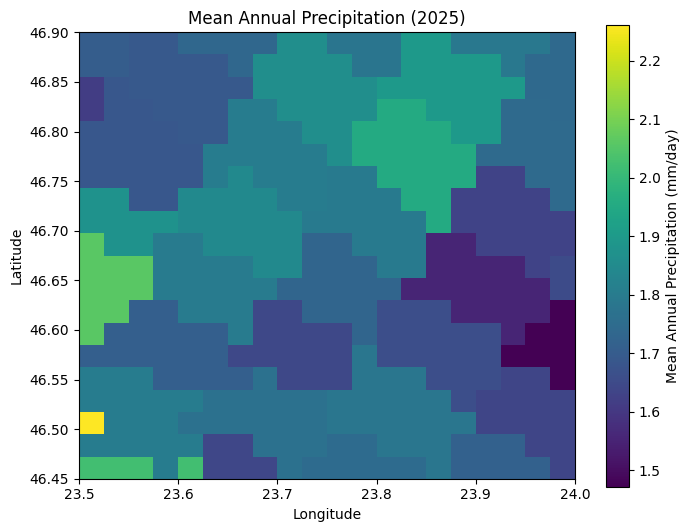

In [21]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

south, north = 46.45, 46.90
west, east = 23.50, 24.00

grid_n = 20  # schimba la 10 pentru mai multa precizie

lats = np.linspace(south, north, grid_n)
lons = np.linspace(west, east, grid_n)

rain_grid = np.zeros((grid_n, grid_n))

for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        url = (
            f"https://archive-api.open-meteo.com/v1/archive?"
            f"latitude={lat}&longitude={lon}"
            f"&start_date=2025-01-01&end_date=2025-12-31"
            f"&daily=precipitation_sum&timezone=Europe%2FBucharest"
        )

        r = requests.get(url).json()
        print(f"Fetched data for {lat:.4f}, {lon:.4f}, no. {i*grid_n + j + 1}/{grid_n**2}")
        df = pd.DataFrame({
            "date": r["daily"]["time"],
            "precip": r["daily"]["precipitation_sum"]
        })

        mean_prec = df["precip"].mean()
        rain_grid[i, j] = mean_prec

# plot
plt.figure(figsize=(8, 6))
plt.imshow(
    rain_grid,
    extent=[west, east, south, north],
    origin="lower"
)

plt.colorbar(label="Mean Annual Precipitation (mm/day)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean Annual Precipitation (2025)")
plt.show()